<a href="https://colab.research.google.com/github/2303A51434/natural-language-processing/blob/main/paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (19200, 5)
Unique values in y: [-447.9329532  -377.82094077 -359.96784384 ...  329.96615615  333.88581747
  375.92310065]
Minimum value in y: -447.9329532
Maximum value in y: 375.92310065
Unique values in processed y: [0 1]
Epoch: 0 Loss: 0.6361668109893799 Accuracy: 0.766015625
Epoch: 1 Loss: 0.6024178266525269 Accuracy: 0.7951822916666667
Epoch: 2 Loss: 0.5744659304618835 Accuracy: 0.8059895833333334
Epoch: 3 Loss: 0.5516525506973267 Accuracy: 0.8104817708333333
Epoch: 4 Loss: 0.5323566794395447 Accuracy: 0.8130208333333333
Epoch: 5 Loss: 0.5157191753387451 Accuracy: 0.8162109375
Epoch: 6 Loss: 0.5013123750686646 Accuracy: 0.81875
Epoch: 7 Loss: 0.4886225461959839 Accuracy: 0.8192057291666667
Epoch: 8 Loss: 0.4775165021419525 Accuracy: 0.8206380208333334
Epoch: 9 Loss: 0.46774327754974365 Accuracy: 0.822265625
Epoch: 10 Loss: 0.4588370621204376 Accuracy: 0.8235026041666667
Epoch: 11 Loss: 0.45069414377212524 Accuracy: 0.8241536458333333
Epoch: 12 Loss: 0.44316360354423

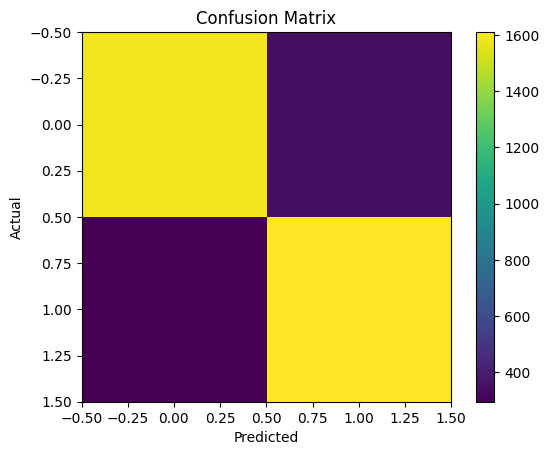

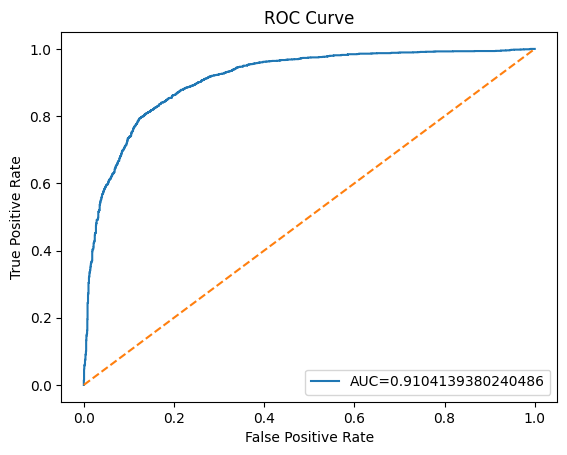

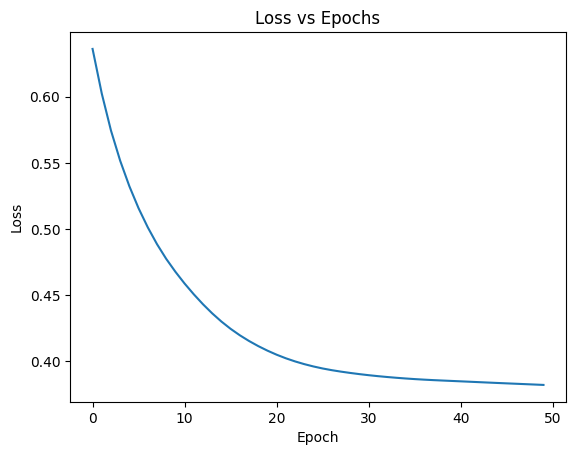

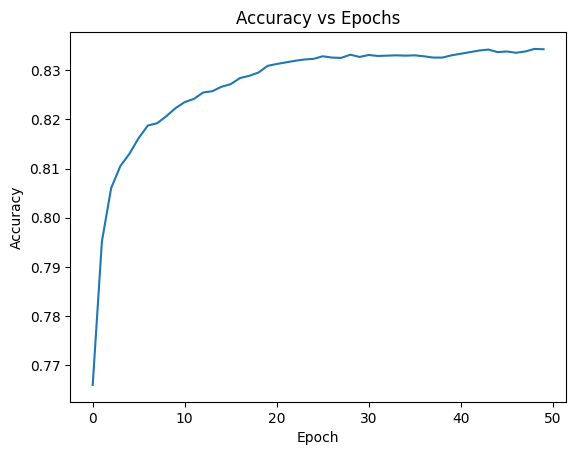

In [2]:
# ==============================
# 1 Install Libraries
# ==============================

!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install scikit-learn

# ==============================
# 2 Import Libraries
# ==============================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt

# ==============================
# 3 Load EEG Dataset
# ==============================

file1 = "/content/S14S1.csv"
file2 = "/content/S14S2.csv"

data1 = pd.read_csv(file1)
data2 = pd.read_csv(file2)

data = pd.concat([data1,data2],axis=0)

print("Dataset Shape:",data.shape)

# ==============================
# 4 Prepare Features and Labels
# ==============================

X = data.iloc[:,:-1].values
y_raw = data.iloc[:,-1].values # Store raw values to process

# Debugging: Print unique values and min/max of y
print("Unique values in y:", np.unique(y_raw))
print("Minimum value in y:", np.min(y_raw))
print("Maximum value in y:", np.max(y_raw))

# Convert continuous y_raw into binary labels (0 or 1) for classification
# For demonstration, using the mean as a threshold. Adjust this based on actual classification criteria.
threshold = np.mean(y_raw)
y = (y_raw > threshold).astype(int)

print("Unique values in processed y:", np.unique(y))

X = torch.tensor(X,dtype=torch.float)
y = torch.tensor(y,dtype=torch.long)

# ==============================
# 5 Create Graph Structure
# ==============================

num_nodes = X.shape[1]

edges = []

for i in range(num_nodes-1):

    edges.append([i,i+1])
    edges.append([i+1,i])

edge_index = torch.tensor(edges).t().contiguous()

# ==============================
# 6 Train Test Split
# ==============================

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# ==============================
# 7 Temporal GNN Model
# ==============================

class TemporalGNN(nn.Module):

    def __init__(self,num_features,hidden_dim):

        super(TemporalGNN,self).__init__()
        # Each feature (EEG channel) is a node, so it has 1 input feature (its value)
        self.gcn1 = GCNConv(1,64)
        self.gcn2 = GCNConv(64,32)
        # LSTM input will be the flattened output of the GCN for all features
        self.lstm = nn.LSTM(32 * num_features,hidden_dim,batch_first=True)

        self.fc = nn.Linear(hidden_dim,2)

    def forward(self,x_batch,edge_index):
        # x_batch is (num_samples, num_features)
        num_samples, num_features = x_batch.shape

        gcn_processed_samples = []
        for i in range(num_samples):
            # Take one sample (num_features,) and reshape to (num_features, 1)
            # to fit GCNConv(num_nodes, in_channels) where in_channels=1
            x_sample = x_batch[i, :].unsqueeze(-1) # (num_features, 1)

            x_gcn = self.gcn1(x_sample,edge_index)
            x_gcn = torch.relu(x_gcn)

            x_gcn = self.gcn2(x_gcn,edge_index)
            x_gcn = torch.relu(x_gcn) # Output shape: (num_features, 32)

            # Flatten the output for this sample to pass to LSTM
            gcn_processed_samples.append(x_gcn.flatten()) # (num_features * 32)

        # Stack all processed samples to form the batch for LSTM
        # Resulting tensor: (num_samples, num_features * 32)
        x_lstm_input = torch.stack(gcn_processed_samples)

        # Add a sequence length dimension of 1 for LSTM (batch_first=True)
        x_lstm_input = x_lstm_input.unsqueeze(1) # (num_samples, 1, num_features * 32)

        lstm_out,_ = self.lstm(x_lstm_input) # (num_samples, 1, hidden_dim)

        # Remove the sequence length dimension (now 1) to get (num_samples, hidden_dim)
        final_lstm_output = lstm_out.squeeze(1)

        out = self.fc(final_lstm_output) # (num_samples, 2)

        return out

# ==============================
# 8 Initialize Model
# ==============================

# Pass X.shape[1] (num_features) to the model constructor
model = TemporalGNN(X.shape[1],32)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

# ==============================
# 9 Training
# ==============================

epochs = 50

loss_list=[]
acc_list=[]

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    output = model(X_train,edge_index)

    loss = criterion(output,y_train)

    loss.backward()

    optimizer.step()

    _,pred = torch.max(output,1)

    acc = (pred==y_train).sum().item()/len(y_train)

    loss_list.append(loss.item())
    acc_list.append(acc)

    print("Epoch:",epoch,
          "Loss:",loss.item(),
          "Accuracy:",acc)

# ==============================
# 10 Evaluation
# ==============================

model.eval()

with torch.no_grad():

    output = model(X_test,edge_index)

    probs = torch.softmax(output,dim=1)[:,1]

    _,pred = torch.max(output,1)

# ==============================
# 11 Confusion Matrix
# ==============================

cm = confusion_matrix(y_test,pred)

print("Confusion Matrix")
print(cm)

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

# ==============================
# 12 ROC Curve
# ==============================

fpr,tpr,_ = roc_curve(y_test,probs)

roc_auc = auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label="AUC="+str(roc_auc))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ==============================
# 13 Loss vs Epochs
# ==============================

plt.figure()

plt.plot(loss_list)

plt.title("Loss vs Epochs")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

# ==============================
# 14 Accuracy vs Epochs
# ==============================

plt.figure()

plt.plot(acc_list)

plt.title("Accuracy vs Epochs")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()